In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

source2 = "../data/interim/03_filtered.parquet"

In [2]:
df = pd.read_parquet(source2)

In [3]:
display(df.head(0))

,address,longitude,latitude,area,room_count,floor,floor_count,market_type,flat_type,ceiling_height,build_year,balcony,price,price_per_square_meter,date


In [4]:
df = df.copy()

df['date'] = pd.to_datetime(df['date'])
df['period'] = df['date'].dt.to_period('M').dt.to_timestamp()

display(df[['date', 'period', 'market_type', 'price_per_square_meter']].head())
display(df['market_type'].value_counts(dropna=False))
print(df['date'].min(), df['date'].max())

,date,period,market_type,price_per_square_meter
0,2025-06-09,2025-06-01,secondary,78299.8
1,2025-05-21,2025-05-01,secondary,312820.5
2,2025-05-06,2025-05-01,secondary,423452.8
3,2025-05-21,2025-05-01,secondary,156069.8
4,2025-06-10,2025-06-01,secondary,79545.5


market_type
primary      1202347
secondary     134056
Name: count, dtype: int64[pyarrow]

2004-04-25 00:00:00 2025-08-01 00:00:00


In [5]:
monthly = (
    df.groupby(['market_type', 'period'], as_index=False)
      .agg(
          price_sqm_median=('price_per_square_meter', 'median'),
          price_sqm_mean=('price_per_square_meter', 'mean'),
          n_obs=('price_per_square_meter', 'size')
      )
      .sort_values(['market_type', 'period'])
)

display(monthly.head(20))

,market_type,period,price_sqm_median,price_sqm_mean,n_obs
0,primary,2004-04-01,133000.00,133000.000000,1
1,primary,2007-10-01,64609.50,64609.500000,2
2,primary,2009-06-01,66667.00,65691.272727,11
3,primary,2009-10-01,64609.50,64609.500000,2
4,primary,2009-11-01,66667.00,65191.875000,8
5,primary,2009-12-01,62552.00,64198.000000,5
6,primary,2013-01-01,77891.00,77891.000000,1
7,primary,2013-02-01,177050.00,177050.000000,1
8,primary,2013-09-01,125692.52,122731.144000,5
9,primary,2013-10-01,136049.00,136049.000000,1


In [6]:
(monthly['price_sqm_mean'] / monthly['price_sqm_median']).describe()

count    312.000000
mean       1.089930
std        0.079874
min        0.868522
25%        1.015077
50%        1.103117
75%        1.147080
max        1.484777
dtype: float64

## Построение discount-функции

Для удаления временного тренда цена за квадратный метр была приведена к единой базе через месячный индекс, рассчитанный отдельно для `primary` и `secondary`. В качестве базовой метрики использовалась медиана, так как среднее оказалось чувствительным к выбросам.

Месячный индекс определяется как:


$\text{discount\_index}_{m,t} = \frac{\mathrm{median}(price\_per\_sqm_{m,t})}{\mathrm{median}(price\_per\_sqm_{m,t_{base}})}$

где \(m\) — тип рынка, \(t\) — месяц, \(t_{base}\) — базовый период.

Реальная цена за квадратный метр рассчитывается как:

$price\_sqm\_real = \frac{price\_per\_sqm}{\text{discount\_index}_{m,t}}$

Это преобразование устраняет временной эффект и делает цены сопоставимыми между разными периодами.

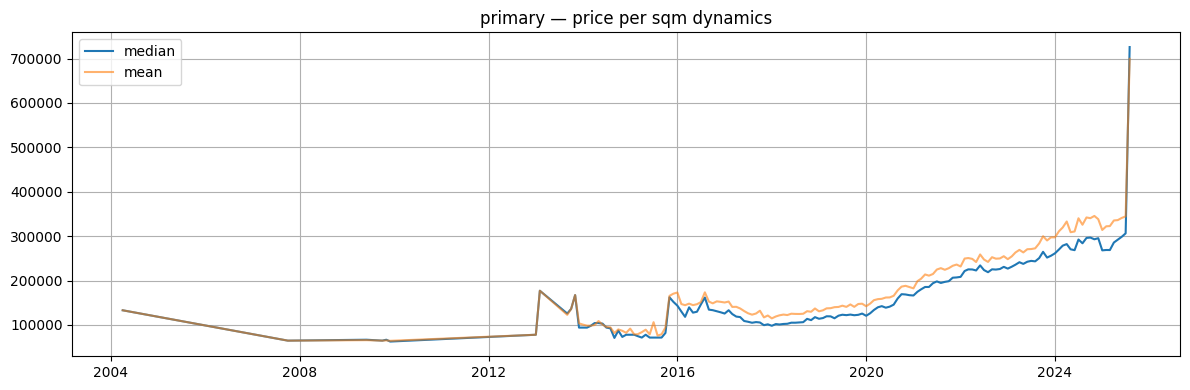

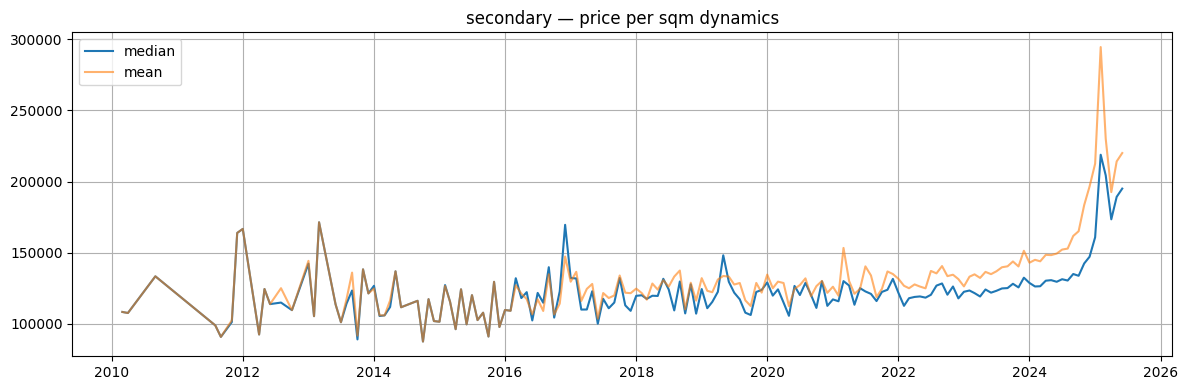

In [37]:
for market in ['primary', 'secondary']:
    tmp = monthly[monthly['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    plt.plot(tmp['period'], tmp['price_sqm_median'], label='median')
    plt.plot(tmp['period'], tmp['price_sqm_mean'], label='mean', alpha=0.6)
    plt.title(f'{market} — price per sqm dynamics')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## Сравнение median и mean

Среднее систематически выше медианы, что указывает на правый хвост распределения и наличие дорогих объектов. На вторичном рынке ряд более шумный из-за меньшего числа наблюдений. В ранних периодах значения нестабильны из-за низкого `n_obs`. Поэтому для построения индекса выбрана медиана как более устойчивая метрика.

In [8]:
min_obs = 30

monthly_primary = (
    monthly[monthly['market_type'] == 'primary']
    .copy()
)

monthly_secondary = (
    monthly[monthly['market_type'] == 'secondary']
    .copy()
)

monthly_primary = monthly_primary[monthly_primary['n_obs'] >= min_obs]

monthly_secondary = monthly_secondary[monthly_secondary['n_obs'] >= min_obs]

monthly_primary = monthly_primary.sort_values('period')

monthly_secondary = monthly_secondary.sort_values('period')

base_value = monthly_primary['price_sqm_median'].iloc[-1]

monthly_primary['discount_index'] = (
    monthly_primary['price_sqm_median'] / base_value
)

base_value = monthly_secondary['price_sqm_median'].iloc[-1]

monthly_secondary['discount_index'] = (
    monthly_secondary['price_sqm_median'] / base_value
)

display(monthly_primary.tail())
display(monthly_secondary.tail())

,market_type,period,price_sqm_median,price_sqm_mean,n_obs,discount_index
146,primary,2025-03-01,268734.855,322702.414343,11622,0.877310
147,primary,2025-04-01,285662.000,335350.999781,10181,0.932570
148,primary,2025-05-01,292138.865,336145.672107,8804,0.953714
149,primary,2025-06-01,298639.660,341097.957179,9084,0.974937
150,primary,2025-07-01,306317.010,344582.461546,7227,1.000000


,market_type,period,price_sqm_median,price_sqm_mean,n_obs,discount_index
307,secondary,2025-02-01,218855.20,294615.184373,9215,1.122099
308,secondary,2025-03-01,204326.90,230096.664233,10669,1.047610
309,secondary,2025-04-01,173419.00,192590.011542,16661,0.889141
310,secondary,2025-05-01,189243.00,214174.653961,35455,0.970273
311,secondary,2025-06-01,195040.95,220062.238138,33486,1.000000


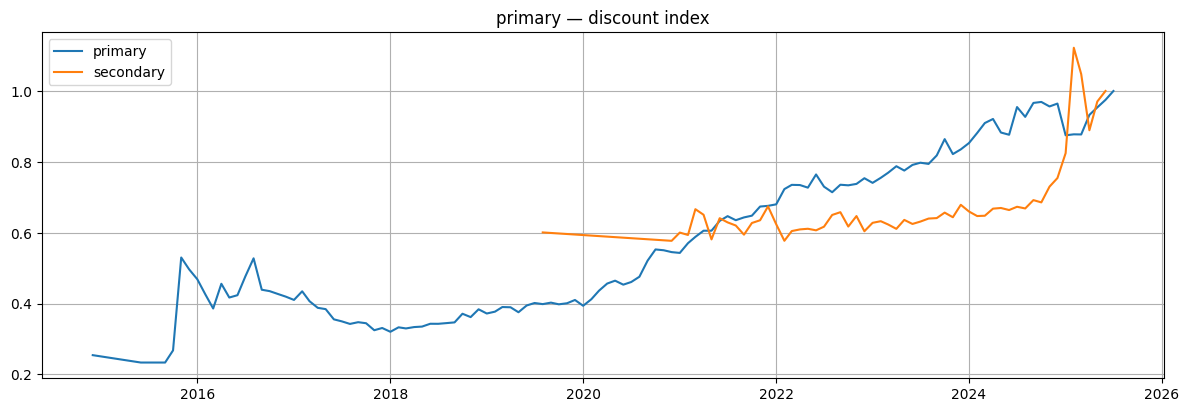

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_primary['period'], monthly_primary['discount_index'], label="primary")
plt.plot(monthly_secondary['period'], monthly_secondary['discount_index'], label="secondary")
plt.legend()
plt.grid()
plt.tight_layout()
plt.title('primary — discount index')
plt.show()

## Discount index

Индекс отражает относительное изменение медианной цены за квадратный метр по времени. На обоих рынках наблюдается рост, но первичка выглядит более гладкой, а вторичка — более волатильной. 

In [10]:
df_primary = df[df['market_type'] == 'primary'].copy()

df_primary = df_primary.merge(
    monthly_primary[['period', 'discount_index']],
    on='period',
    how='left'
)

df_primary['price_sqm_real'] = (
    df_primary['price_per_square_meter'] /
    df_primary['discount_index']
)

In [11]:
min_obs = 30

result_parts = []
index_parts = []

for market in df['market_type'].unique():
    
    tmp = monthly[monthly['market_type'] == market].copy()
    
    tmp = tmp[tmp['n_obs'] >= min_obs].sort_values('period')
    
    base_value = tmp['price_sqm_median'].iloc[-1]
    
    tmp['discount_index'] = tmp['price_sqm_median'] / base_value
    
    index_parts.append(tmp.assign(base_value=base_value))
    
    df_part = df[df['market_type'] == market].copy()
    
    df_part = df_part.merge(
        tmp[['period', 'discount_index']],
        on='period',
        how='left'
    )
    
    df_part['price_sqm_real'] = (
        df_part['price_per_square_meter'] /
        df_part['discount_index']
    )
    
    result_parts.append(df_part)

result_df = pd.concat(result_parts, ignore_index=True)
index_df = pd.concat(index_parts, ignore_index=True)

In [12]:
display(result_df.head(1))

,address,longitude,latitude,area,room_count,floor,floor_count,market_type,flat_type,ceiling_height,build_year,balcony,price,price_per_square_meter,date,period,discount_index,price_sqm_real
0,"Коммунистическая, д. 26",37.580768,55.505888,44.7,2,2,5,secondary,flat,NaN,<NA>,False,3500000.0,78299.8,2025-06-09,2025-06-01,1.0,78299.8


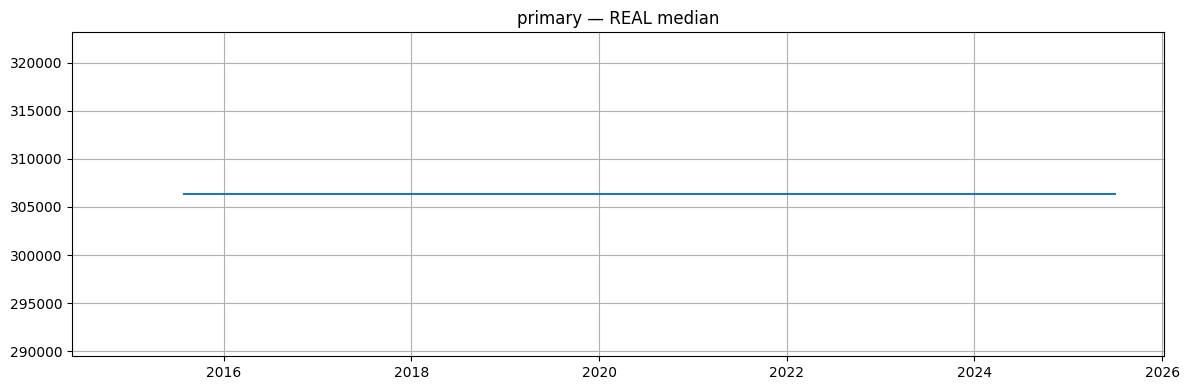

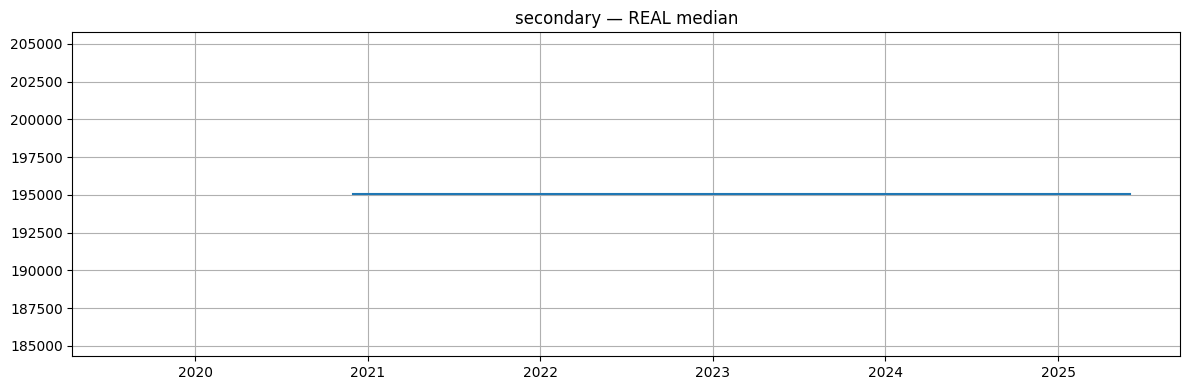

In [13]:
check_median = (
    result_df.groupby(['market_type', 'period'], as_index=False)
    .agg(real_price_median=('price_sqm_real', 'median'))
)

for market in check_median['market_type'].unique():
    tmp = check_median[check_median['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    plt.plot(tmp['period'], tmp['real_price_median'])
    plt.title(f'{market} — REAL median')
    plt.grid()
    plt.tight_layout()
    plt.show()

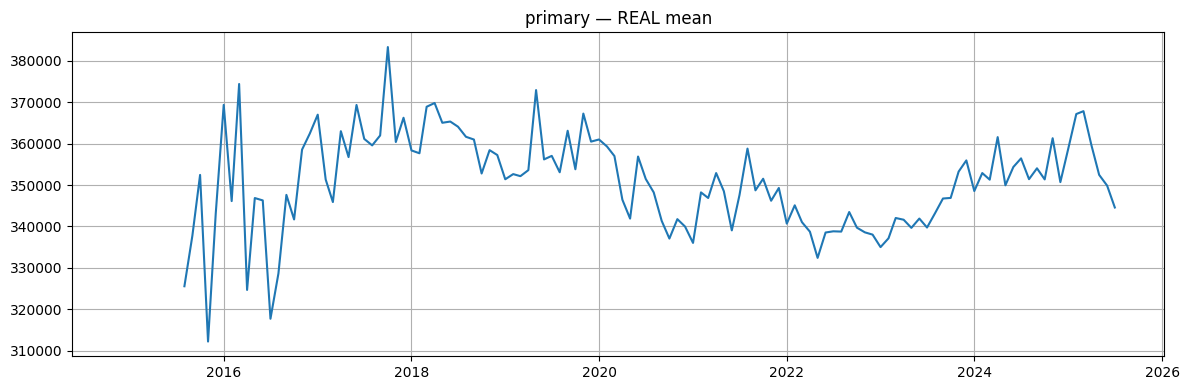

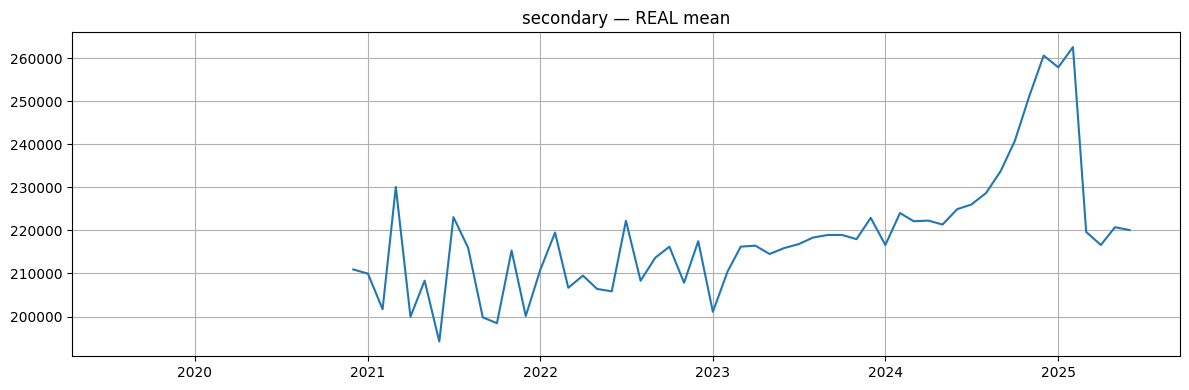

In [14]:
check_mean = (
    result_df.groupby(['market_type', 'period'], as_index=False)
    .agg(real_price_mean=('price_sqm_real', 'mean'))
)

for market in check_mean['market_type'].unique():
    tmp = check_mean[check_mean['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    plt.plot(tmp['period'], tmp['real_price_mean'])
    plt.title(f'{market} — REAL mean')
    plt.grid()
    plt.tight_layout()
    plt.show()

## Проверка дисконтирования

После применения discount-функции медианный ряд `price_sqm_real` стал константным, что подтверждает корректность метода. Средний ряд остаётся шумным из-за выбросов. Это ожидаемо, поскольку индекс строился по медиане. Таким образом, временной тренд успешно устранён.

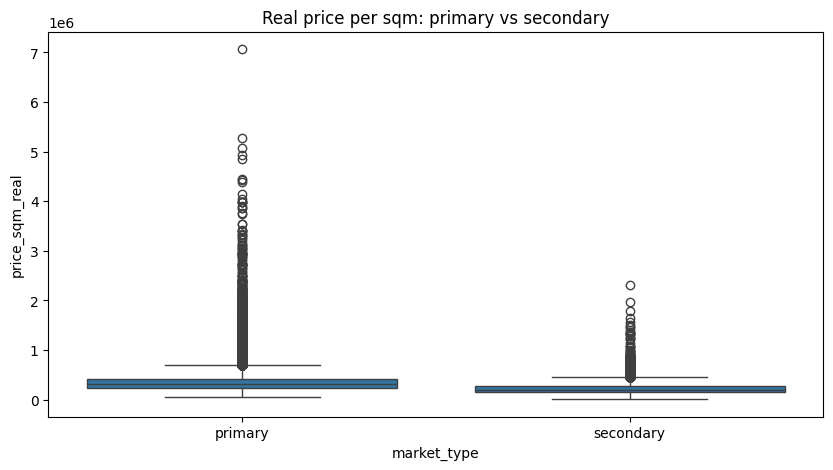

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=result_df.sample(100_000),
    x='market_type',
    y='price_sqm_real'
)

plt.title('Real price per sqm: primary vs secondary')
plt.show()

## Сравнение распределений

Первичный рынок остаётся дороже вторичного даже после удаления временного тренда. Медиана `price_sqm_real` в первичке примерно на 50–60% выше. Также у первички более выраженный верхний хвост. Это указывает на устойчивую премию первичного рынка.

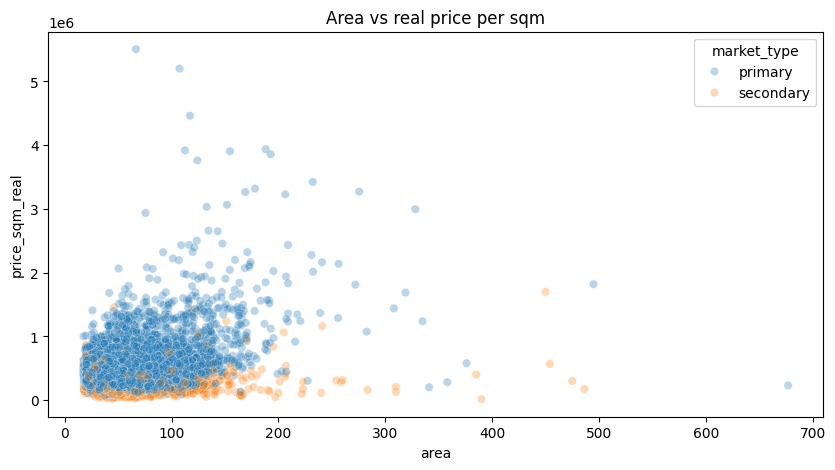

In [16]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=result_df.sample(50_000),
    x='area',
    y='price_sqm_real',
    hue='market_type',
    alpha=0.3
)

plt.title('Area vs real price per sqm')
plt.show()

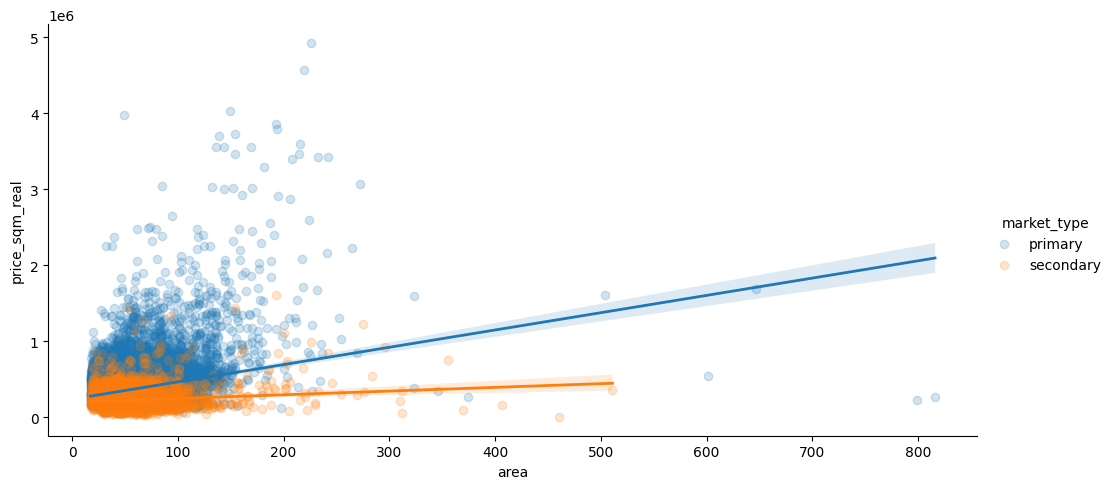

In [17]:
sns.lmplot(
    data=result_df.sample(50_000),
    x='area',
    y='price_sqm_real',
    hue='market_type',
    scatter_kws={'alpha': 0.2},
    line_kws={'linewidth': 2},
    height=5,
    aspect=2
)

## Площадь и цена за метр

Существует зависимость между площадью и ценой за метр. В среднем более крупные квартиры имеют более высокую цену за квадратный метр. Первичный рынок при сопоставимых площадях расположен выше вторичного. 

In [19]:
numeric_cols = [
    'price_sqm_real',
    'area',
    'room_count',
    'floor',
    'floor_count',
    'ceiling_height',
    'build_year'
]

corr = result_df[numeric_cols].corr(method="spearman")

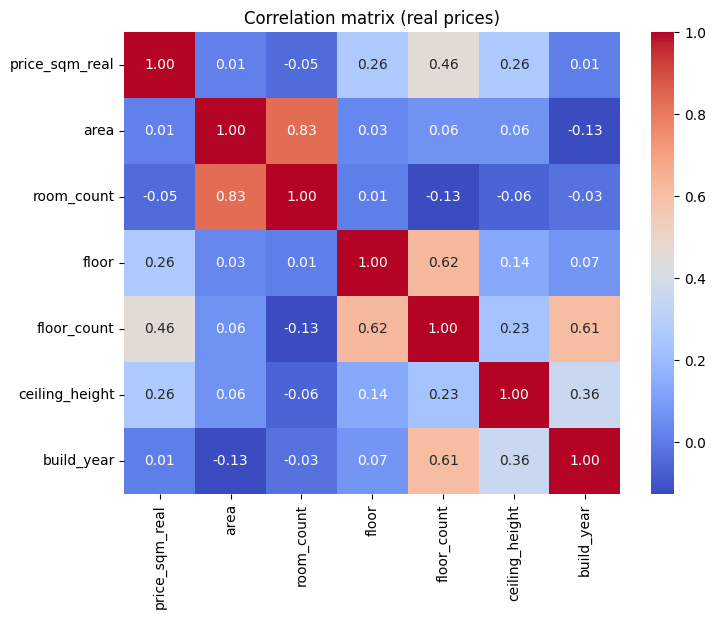

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title('Correlation matrix (real prices)')
plt.show()

In [21]:
result_df.groupby('market_type')['price_sqm_real'].describe()

,count,mean,std,min,25%,50%,75%,max
market_type,,,,,,,,
primary,1202042.0,351641.685393,186412.427501,60440.847398,237982.071423,306317.01,420882.034077,1.020206e+07
secondary,133104.0,224855.840166,122470.312092,4368.975820,150523.365559,195040.95,268038.468779,2.877138e+06


In [22]:
(
    result_df.groupby('market_type')['price_sqm_real']
    .median()
)

market_type
primary      306317.01
secondary    195040.95
Name: price_sqm_real, dtype: float64

In [24]:
q = 0.95

q95_df = (
    result_df.groupby(['market_type', 'period'], as_index=False)
    .agg(
        q95_nominal=('price_per_square_meter', lambda x: x.quantile(q)),
        q95_real=('price_sqm_real', lambda x: x.quantile(q)),
        n_obs=('price_per_square_meter', 'size')
    )
)

In [25]:
min_obs = 30

q95_df = q95_df[q95_df['n_obs'] >= min_obs]

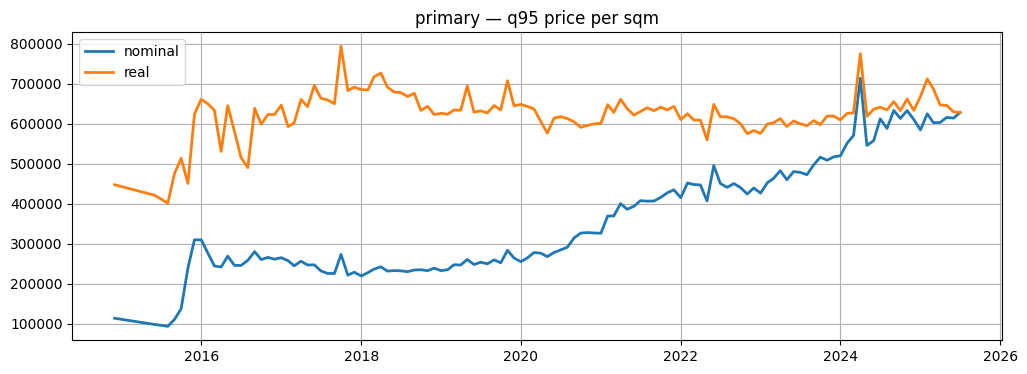

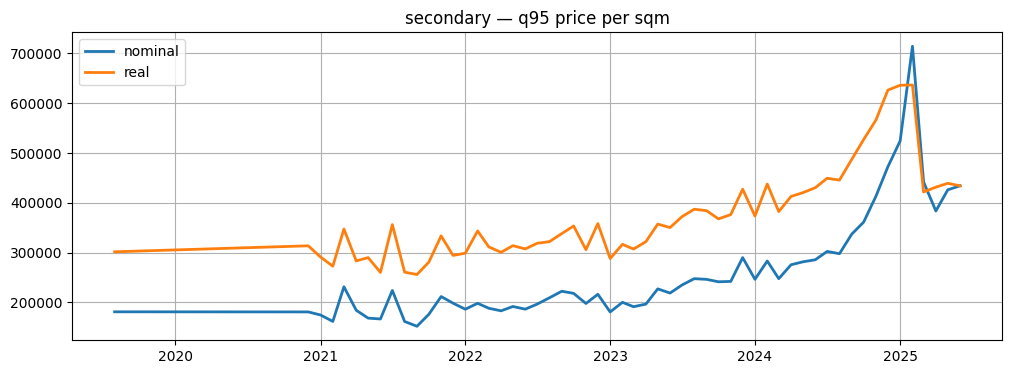

In [26]:
for market in q95_df['market_type'].unique():
    
    tmp = q95_df[q95_df['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(tmp['period'], tmp['q95_nominal'], label='nominal', linewidth=2)
    plt.plot(tmp['period'], tmp['q95_real'], label='real', linewidth=2)
    
    
    plt.title(f'{market} — q95 price per sqm')
    plt.legend()
    plt.grid()
    plt.show()

## Верхний сегмент (q95)

Номинальный q95 растёт на обоих рынках, отражая общий рост цен. После дисконтирования динамика становится значительно более стабильной. На вторичном рынке реальный q95 остаётся более волатильным. Это может указывать на дополнительную динамику верхнего сегмента.

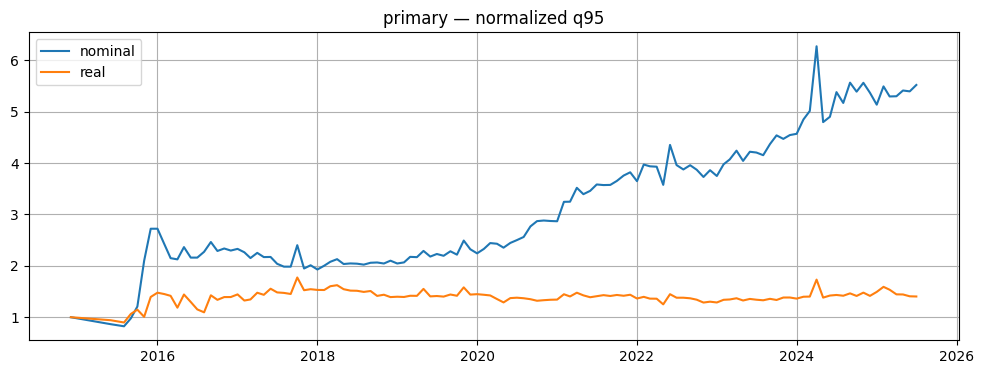

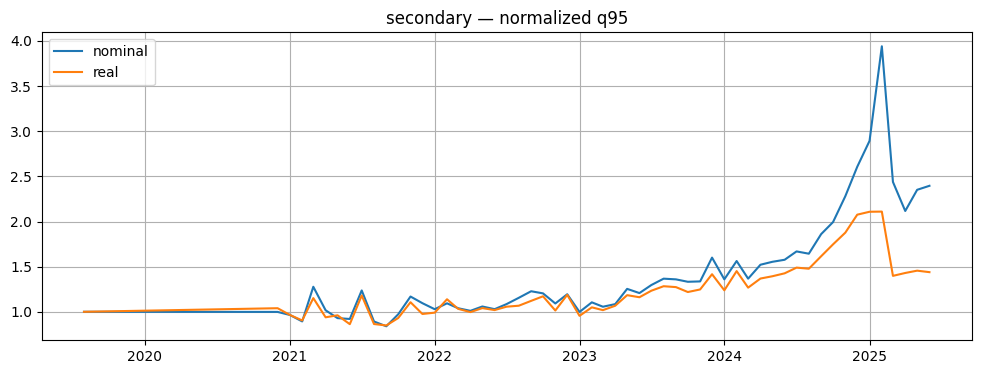

In [27]:
for market in q95_df['market_type'].unique():
    
    tmp = q95_df[q95_df['market_type'] == market].copy()
    
    tmp['nominal_norm'] = tmp['q95_nominal'] / tmp['q95_nominal'].iloc[0]
    tmp['real_norm'] = tmp['q95_real'] / tmp['q95_real'].iloc[0]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(tmp['period'], tmp['nominal_norm'], label='nominal')
    plt.plot(tmp['period'], tmp['real_norm'], label='real')
    
    plt.title(f'{market} — normalized q95')
    plt.legend()
    plt.grid()
    plt.show()

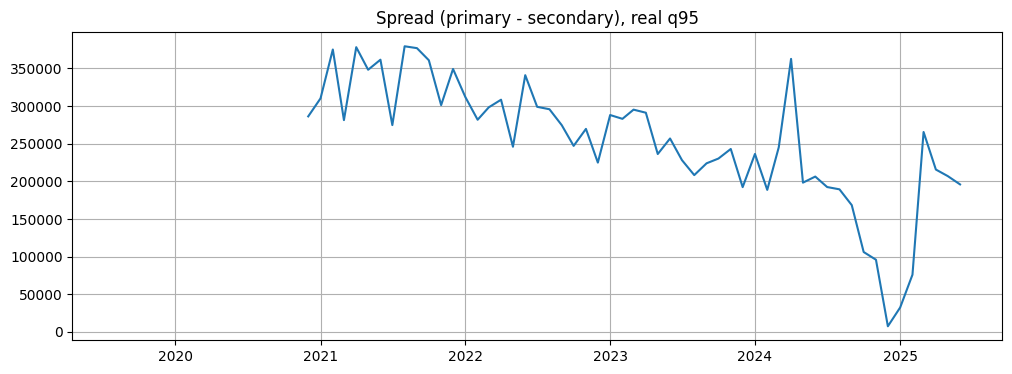

In [28]:
pivot = q95_df.pivot(
    index='period',
    columns='market_type',
    values='q95_real'
)

pivot['spread'] = pivot['primary'] - pivot['secondary']

plt.figure(figsize=(12, 4))
plt.plot(pivot.index, pivot['spread'])
plt.title('Spread (primary - secondary), real q95')
plt.grid()
plt.show()

## Спред между рынками (q95)

Верхний сегмент первички остаётся дороже вторички на всём интервале. При этом разрыв со временем сокращается. В конце периода наблюдается рост волатильности. Это указывает на частичное сближение рынков в дорогом сегменте.

In [29]:
q_df = (
    result_df.groupby(['market_type', 'period'], as_index=False)
    .agg(
        q05=('price_sqm_real', lambda x: x.quantile(0.05)),
        q50=('price_sqm_real', 'median'),
        q95=('price_sqm_real', lambda x: x.quantile(0.95)),
        n_obs=('price_sqm_real', 'size')
    )
)

In [30]:
min_obs = 30
q_df = q_df[q_df['n_obs'] >= min_obs]

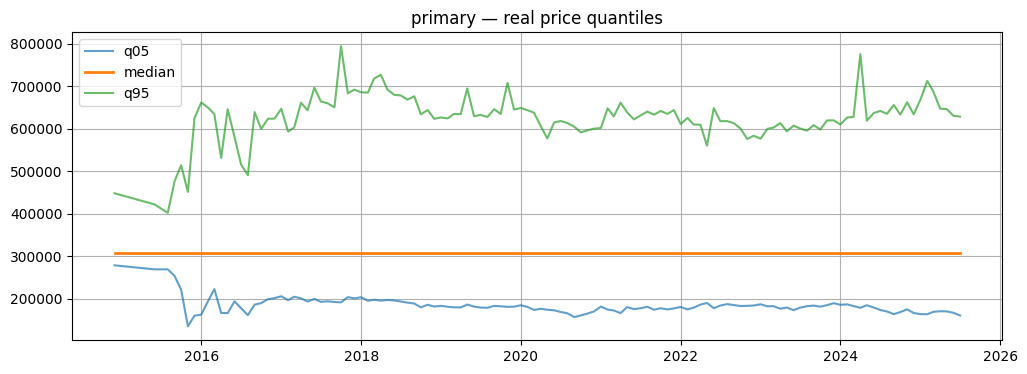

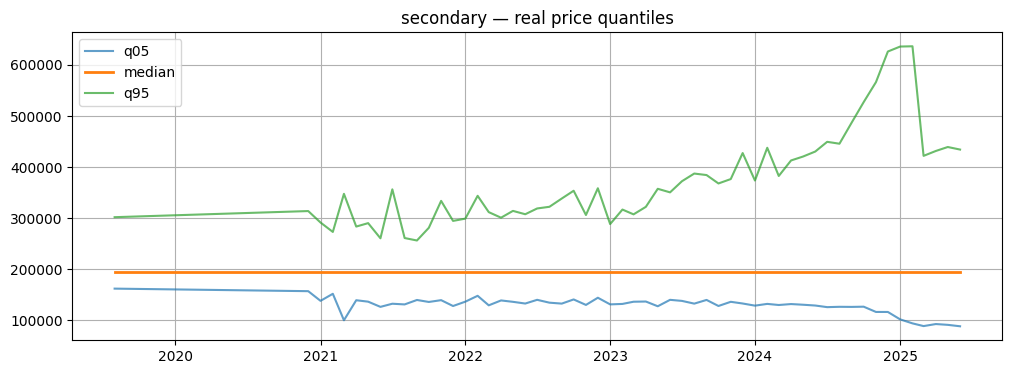

In [31]:
for market in q_df['market_type'].unique():
    
    tmp = q_df[q_df['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    
    plt.plot(tmp['period'], tmp['q05'], label='q05', alpha=0.7)
    plt.plot(tmp['period'], tmp['q50'], label='median', linewidth=2)
    plt.plot(tmp['period'], tmp['q95'], label='q95', alpha=0.7)
    
    plt.title(f'{market} — real price quantiles')
    plt.legend()
    plt.grid()
    plt.show()

## Квантили распределения

После дисконтирования медиана остаётся стабильной, но крайние квантили сохраняют динамику. На вторичном рынке наблюдается расхождение верхнего и нижнего сегментов. Это означает усиление внутренней неоднородности. В первичке структура более стабильна.

In [32]:
q_df['spread'] = q_df['q95'] - q_df['q05']
q_df['ratio'] = q_df['q95'] / q_df['q05']

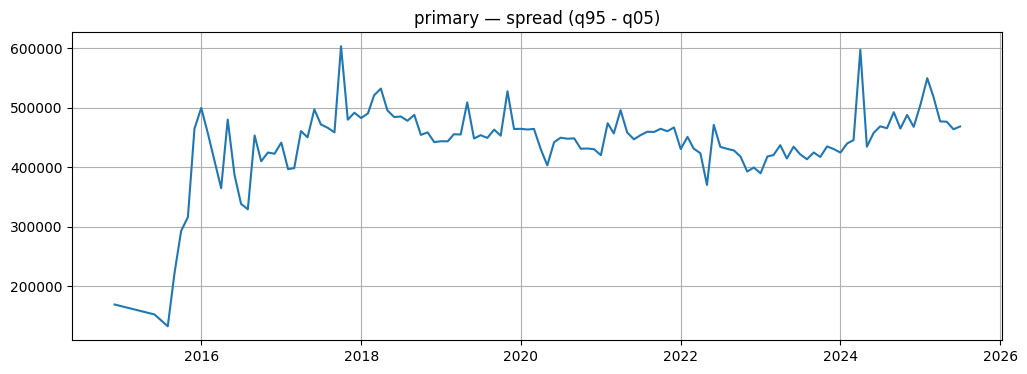

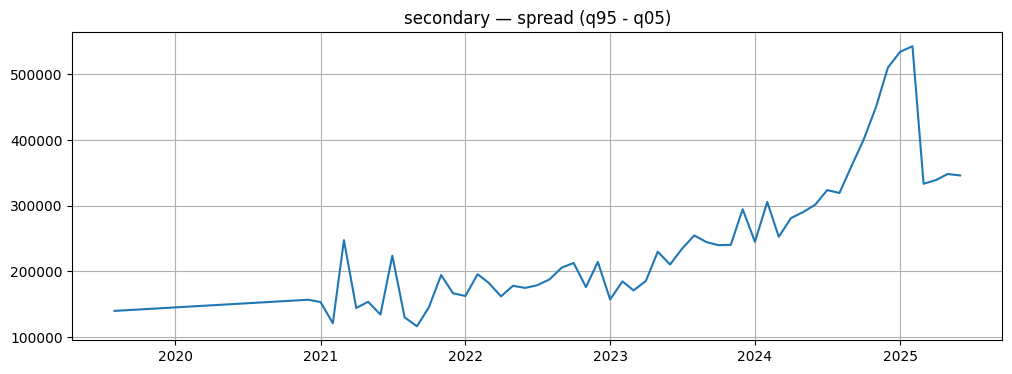

In [33]:
for market in q_df['market_type'].unique():
    
    tmp = q_df[q_df['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    plt.plot(tmp['period'], tmp['spread'])
    plt.title(f'{market} — spread (q95 - q05)')
    plt.grid()
    plt.show()

## Ширина рынка

Спред между q95 и q05 отражает абсолютную неоднородность рынка. На вторичном рынке он заметно растёт со временем. На первичном рынке остаётся относительно стабильным. Это указывает на усиление сегментации вторички.

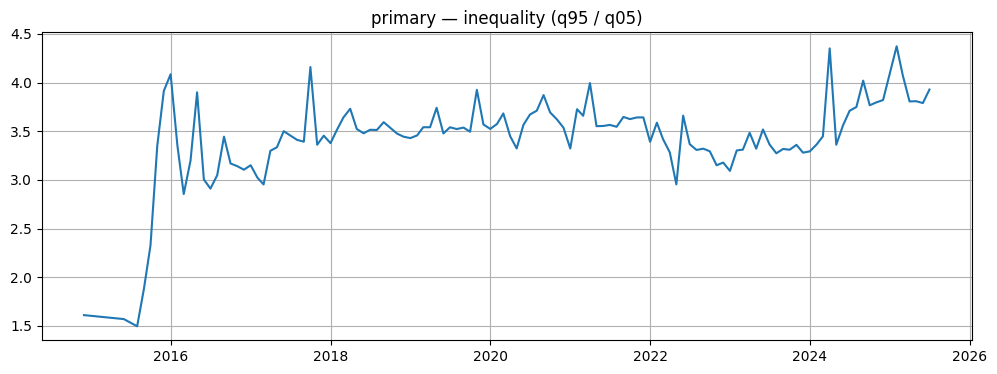

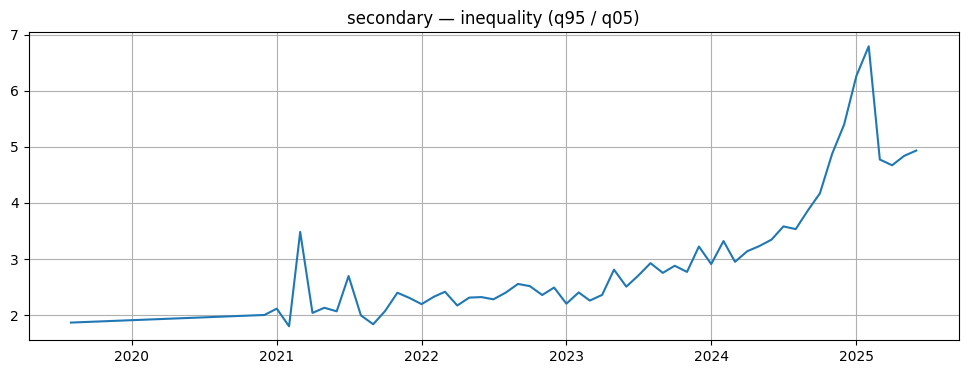

In [34]:
for market in q_df['market_type'].unique():
    
    tmp = q_df[q_df['market_type'] == market]
    
    plt.figure(figsize=(12, 4))
    plt.plot(tmp['period'], tmp['ratio'])
    plt.title(f'{market} — inequality (q95 / q05)')
    plt.grid()
    plt.show()

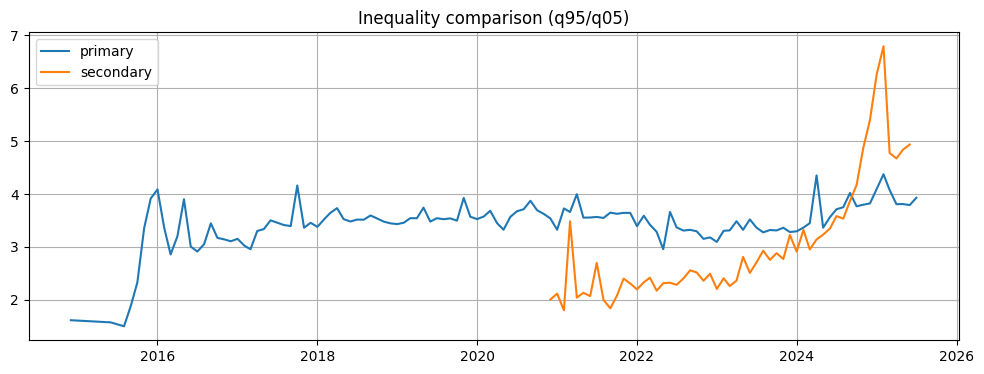

In [35]:
pivot_ratio = q_df.pivot(
    index='period',
    columns='market_type',
    values='ratio'
)

plt.figure(figsize=(12, 4))
plt.plot(pivot_ratio.index, pivot_ratio['primary'], label='primary')
plt.plot(pivot_ratio.index, pivot_ratio['secondary'], label='secondary')

plt.title('Inequality comparison (q95/q05)')
plt.legend()
plt.grid()
plt.show()

## Неравенство (q95 / q05)

Отношение q95 к q05 показывает степень расслоения рынка. На вторичном рынке этот показатель растёт быстрее и достигает более высоких значений. На первичном рынке он более стабилен. Это подтверждает усиление неравномерности вторички.

## Итоговый датафрейм

В результате построения discount-функции был сформирован итоговый датафрейм `result_df`, содержащий как исходные признаки объектов, так и рассчитанные показатели. Ключевыми добавленными переменными являются `discount_index` и `price_sqm_real`, позволяющие работать с ценами в сопоставимом временном масштабе.  

Таким образом, `result_df` может использоваться для дальнейшего анализа и моделирования без искажения, связанного с временной динамикой рынка.

Основные поля:
- `price_per_square_meter` — исходная (номинальная) цена за м²  
- `discount_index` — временной индекс  
- `price_sqm_real` — приведённая (реальная) цена за м²  
- `market_type`, `area`, `room_count` и др. — характеристики объекта

In [36]:
display(result_df.head(3))

,address,longitude,latitude,area,room_count,floor,floor_count,market_type,flat_type,ceiling_height,build_year,balcony,price,price_per_square_meter,date,period,discount_index,price_sqm_real,log_price
0,"Коммунистическая, д. 26",37.580768,55.505888,44.7,2,2,5,secondary,flat,NaN,<NA>,False,3500000.0,78299.8,2025-06-09,2025-06-01,1.000000,78299.800000,11.268300
1,"Рябиновая, д. 3, к. 1",37.424902,55.718709,19.5,0,1,15,secondary,studio,NaN,<NA>,False,6100000.0,312820.5,2025-05-21,2025-05-01,0.970273,322404.567141,12.683562
2,"Большая Очаковская, д. 3",37.465910,55.688563,61.4,2,18,24,secondary,flat,NaN,<NA>,False,26000000.0,423452.8,2025-05-06,2025-05-01,0.970273,436426.374514,12.986375


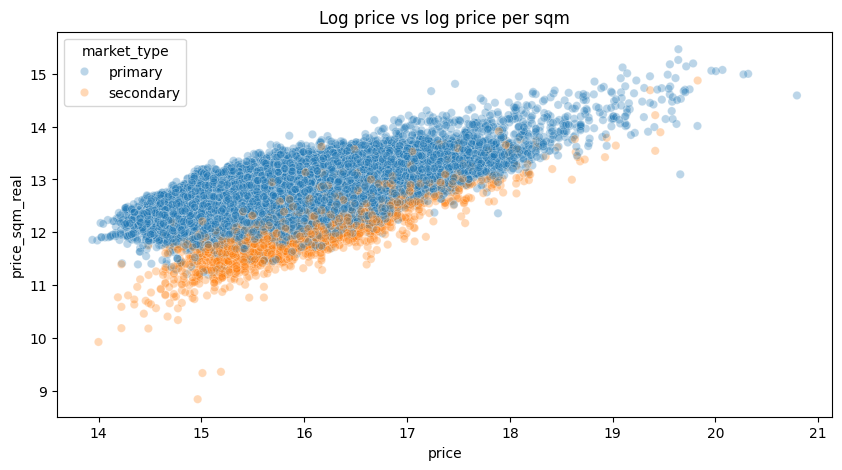

In [40]:
tmp = result_df.sample(50_000).copy()

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=tmp,
    x=np.log(tmp['price']),
    y=np.log(tmp['price_sqm_real']),
    hue=tmp['market_type'],
    alpha=0.3
)

plt.title('Log price vs log price per sqm')
plt.show()

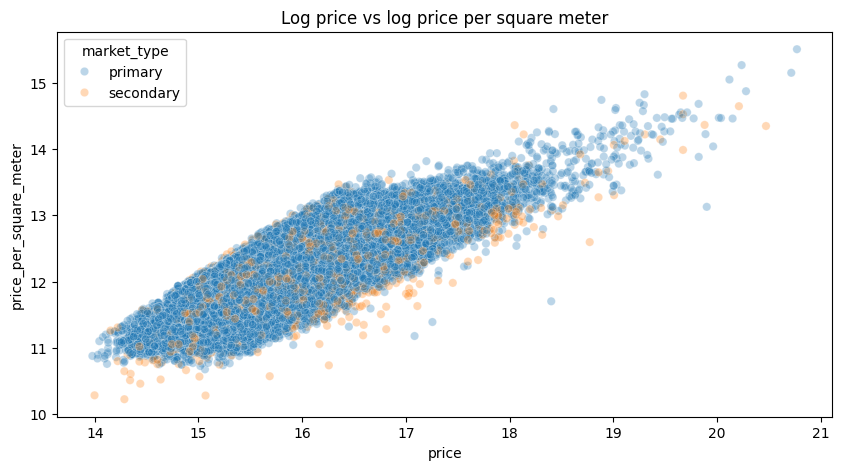

In [48]:
tmp = result_df.sample(50_000).copy()

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=tmp,
    x=np.log(tmp['price']),
    y=np.log(tmp['price_per_square_meter']),
    hue=tmp['market_type'],
    alpha=0.3
)

plt.title('Log price vs log price per square meter')
plt.show()